# 1. NYC Citi Bike Exploratory Data Analysis

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

user_type_counts = pd.read_csv(
    "../data/processed/citibike_cleaned_features.csv",
    usecols=["member_casual"]
)["member_casual"].value_counts()

print(user_type_counts)

member_casual
member    6467099
casual     837395
Name: count, dtype: int64


## 1.1 Ride Count by User Type

This analysis compares the number of rides taken
by members and casual users during January–March 2025.

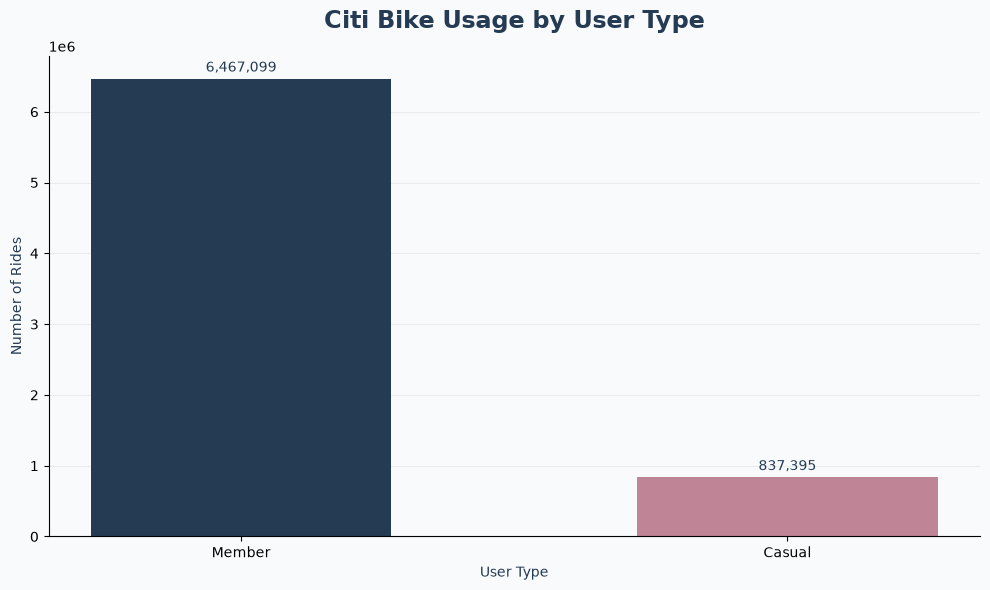

In [2]:
# Modern Professional User Type Graph

import matplotlib.pyplot as plt

NAVY = "#243B53"
ROSE = "#C08497"
BACKGROUND = "#F8FAFC"

labels = ["Member", "Casual"]
values = [6467099, 837395]

colors = [NAVY, ROSE]

fig, ax = plt.subplots(figsize=(10, 6))

fig.patch.set_facecolor(BACKGROUND)
ax.set_facecolor(BACKGROUND)

bars = ax.bar(
    labels,
    values,
    color=colors,
    width=0.55
)

ax.set_title(
    "Citi Bike Usage by User Type",
    fontsize=17,
    fontweight="bold",
    color=NAVY,
    pad=20
)

ax.set_xlabel("User Type", color=NAVY)
ax.set_ylabel("Number of Rides", color=NAVY)

for bar, value in zip(bars, values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value + 100000,
        f"{value:,.0f}",
        ha="center",
        fontsize=10,
        color=NAVY
    )

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", alpha=0.2)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

### Interpretation

- Members account for the majority of rides.
- Casual users account for fewer rides.
- Member rides are significantly higher than casual rides.

This shows that membership users contributed most of the
Citi Bike rides during January–March 2025.

## 1.2 Rides by Day of Week

This analysis examines the number of Citi Bike rides
taken on each day of the week.

The purpose is to identify weekly usage patterns
during January–March 2025.

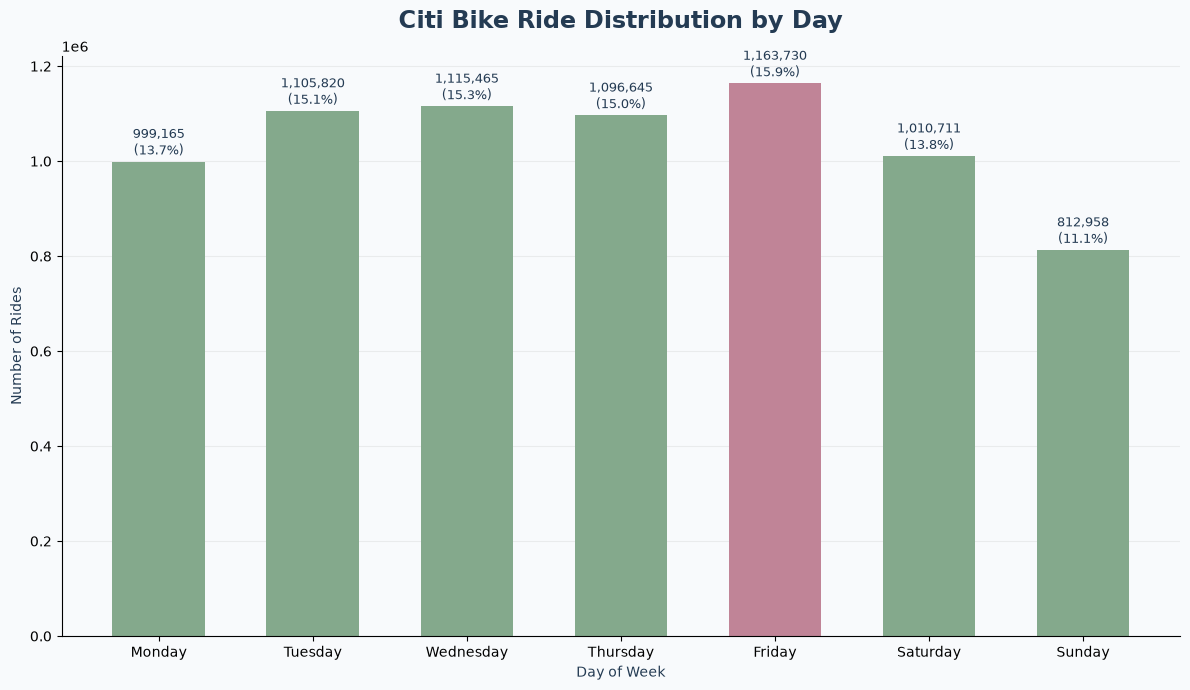

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# Load day-of-week data
day_counts = pd.read_csv(
    "../data/processed/citibike_cleaned_features.csv",
    usecols=["day_of_week"]
)["day_of_week"].value_counts()

day_order = [
    "Monday", "Tuesday", "Wednesday",
    "Thursday", "Friday", "Saturday", "Sunday"
]

day_counts = day_counts.reindex(day_order)

# Define correct variables
days = day_counts.index
values = day_counts.values

# Professional colors
SAGE = "#84A98C"
ROSE = "#C08497"
NAVY = "#243B53"
BACKGROUND = "#F8FAFC"

colors = [
    ROSE if value == values.max() else SAGE
    for value in values
]

# Create graph
fig, ax = plt.subplots(figsize=(12, 7))

fig.patch.set_facecolor(BACKGROUND)
ax.set_facecolor(BACKGROUND)

bars = ax.bar(days, values, color=colors, width=0.6)

ax.set_title(
    "Citi Bike Ride Distribution by Day",
    fontsize=17,
    fontweight="bold",
    color=NAVY,
    pad=20
)

ax.set_xlabel("Day of Week", color=NAVY)
ax.set_ylabel("Number of Rides", color=NAVY)

# Add labels
for bar, value in zip(bars, values):
    percentage = (value / values.sum()) * 100

    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value + 15000,
        f"{value:,.0f}\n({percentage:.1f}%)",
        ha="center",
        fontsize=9,
        color=NAVY
    )

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", alpha=0.2)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

### Interpretation

- Friday recorded the highest number of rides.
- Sunday recorded the lowest number of rides.
- Weekday rides were generally higher than Sunday rides.
- Friday accounted for approximately 15.9% of total rides.

This analysis helps identify weekly usage patterns
and potential differences between weekdays and weekends.

## 1.3 Rides by Hour of the Day

This analysis examines the number of Citi Bike rides
taken during each hour of the day.

The purpose is to identify peak usage hours
during January–March 2025.

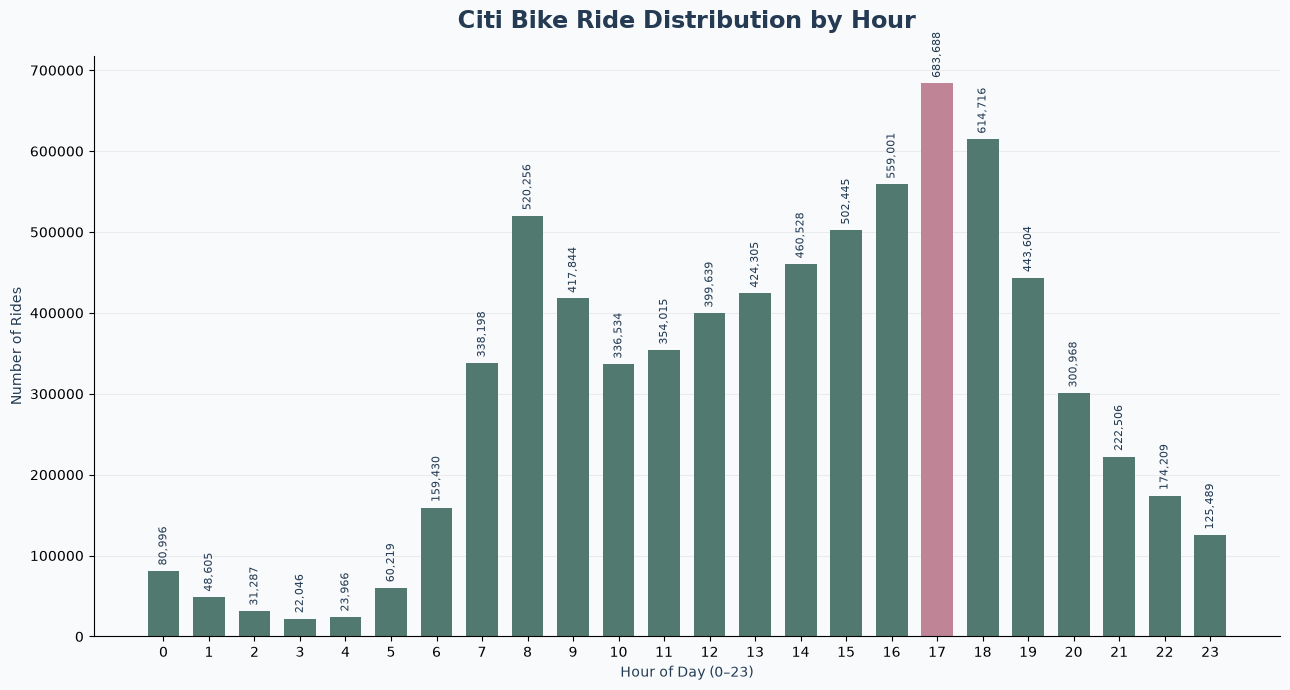

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# Load hour data
hour_counts = pd.read_csv(
    "../data/processed/citibike_cleaned_features.csv",
    usecols=["hour"]
)["hour"].value_counts().sort_index()

hours = hour_counts.index
values = hour_counts.values

# Professional colors
NAVY = "#243B53"
TEAL = "#52796F"
ROSE = "#C08497"
BACKGROUND = "#F8FAFC"

# Highlight the busiest hour
colors = [
    ROSE if value == values.max() else TEAL
    for value in values
]

fig, ax = plt.subplots(figsize=(13, 7))

fig.patch.set_facecolor(BACKGROUND)
ax.set_facecolor(BACKGROUND)

bars = ax.bar(
    hours,
    values,
    color=colors,
    width=0.7
)

ax.set_title(
    "Citi Bike Ride Distribution by Hour",
    fontsize=17,
    fontweight="bold",
    color=NAVY,
    pad=20
)

ax.set_xlabel("Hour of Day (0–23)", color=NAVY)
ax.set_ylabel("Number of Rides", color=NAVY)

ax.set_xticks(range(24))

# Display values above bars
for bar, value in zip(bars, values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value + values.max() * 0.01,
        f"{value:,.0f}",
        ha="center",
        va="bottom",
        fontsize=8,
        rotation=90,
        color=NAVY
    )

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", alpha=0.2)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

### Interpretation

- Ride activity is highest around 17:00 (5 PM).
- The second-highest activity occurs around 18:00 (6 PM).
- Morning activity increases between 6 AM and 9 AM.
- Ride activity is relatively low during late-night and early-morning hours.

This analysis helps identify peak travel hours
and daily usage patterns.

## 1.4 Monthly Ride Trends

This analysis compares the number of Citi Bike rides
across January, February, and March 2025.

The purpose is to understand monthly changes
in ride demand.

month
1    2119748
2    2026061
3    3158503
Name: count, dtype: int64


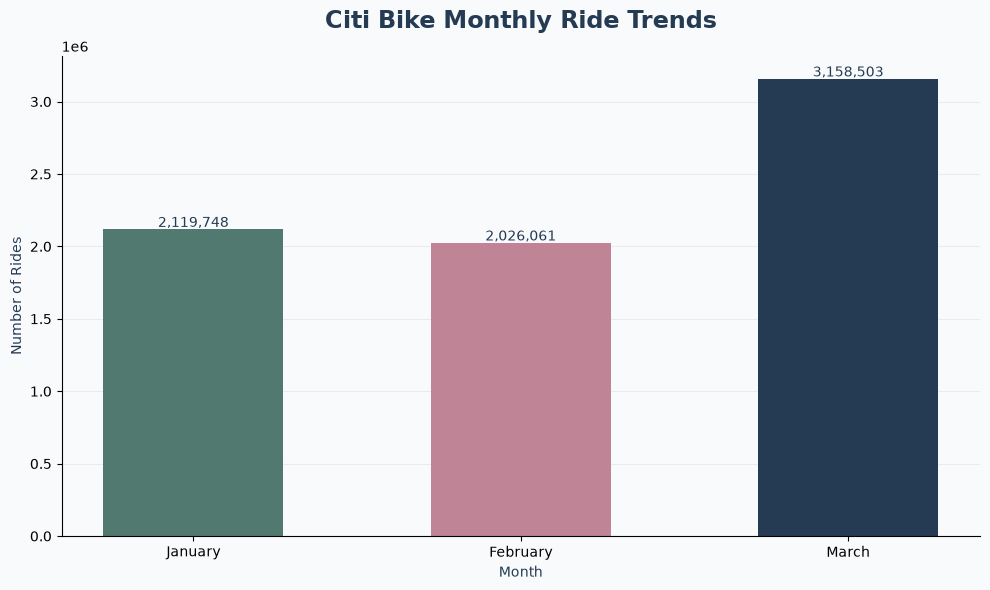

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# Load month data
month_data = pd.read_csv(
    "../data/processed/citibike_cleaned_features.csv",
    usecols=["month"]
)["month"]

# Convert to numbers and remove invalid values
month_data = pd.to_numeric(
    month_data,
    errors="coerce"
).dropna().astype(int)

# Count rides for each month
month_counts = (
    month_data.value_counts()
    .reindex([1, 2, 3], fill_value=0)
)

# Fixed labels (avoids NaN mapping errors)
months = ["January", "February", "March"]
values = month_counts.values

print(month_counts)

# Professional theme
NAVY = "#243B53"
TEAL = "#52796F"
ROSE = "#C08497"
BACKGROUND = "#F8FAFC"

colors = [TEAL, ROSE, NAVY]

fig, ax = plt.subplots(figsize=(10, 6))

fig.patch.set_facecolor(BACKGROUND)
ax.set_facecolor(BACKGROUND)

bars = ax.bar(
    months,
    values,
    color=colors,
    width=0.55
)

ax.set_title(
    "Citi Bike Monthly Ride Trends",
    fontsize=17,
    fontweight="bold",
    color=NAVY,
    pad=20
)

ax.set_xlabel("Month", color=NAVY)
ax.set_ylabel("Number of Rides", color=NAVY)

# Add labels
for bar, value in zip(bars, values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value + 15000,
        f"{value:,.0f}",
        ha="center",
        fontsize=10,
        color=NAVY
    )

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", alpha=0.2)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

### Interpretation

- January recorded 2,119,748 rides.
- February recorded 2,026,061 rides.
- March recorded the highest number of rides, with 3,158,503 rides.
- February recorded the lowest number of rides among the three months.
- Ride counts increased significantly in March compared with February.

This analysis helps us understand monthly changes
in Citi Bike ride demand during January–March 2025.

## 1.5 Average Trip Duration by User Type

This analysis compares the average trip duration
of members and casual users.

The purpose is to understand how travel duration
differs between the two user categories.

member_casual
member     9.695350
casual    15.574628
Name: trip_duration, dtype: float64


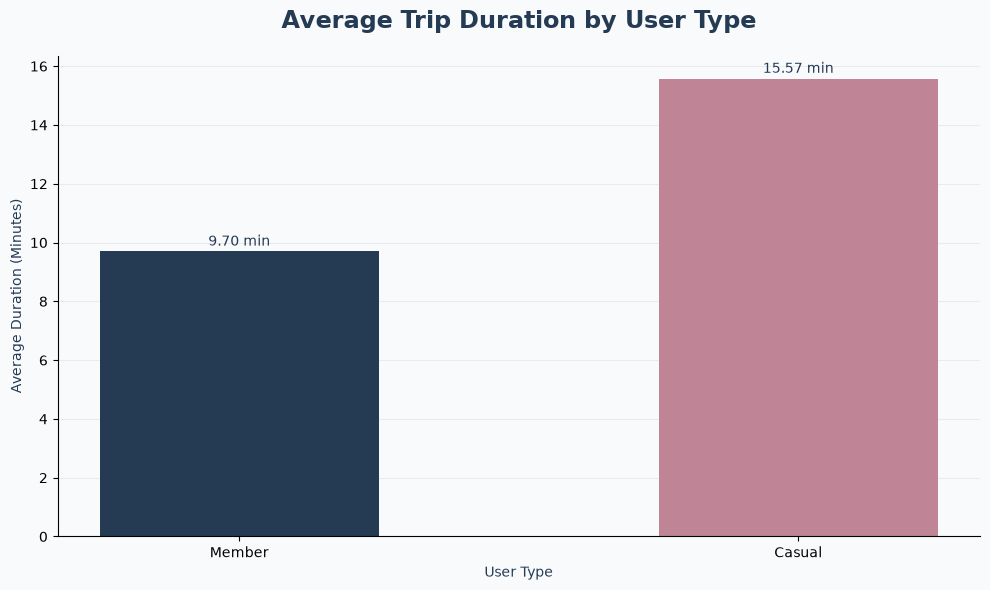

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

# Load only required columns
duration_data = pd.read_csv(
    "../data/processed/citibike_cleaned_features.csv",
    usecols=["member_casual", "trip_duration"]
)

# Calculate average duration
avg_duration = (
    duration_data
    .groupby("member_casual")["trip_duration"]
    .mean()
    .reindex(["member", "casual"])
)

print(avg_duration)

# Professional theme
NAVY = "#243B53"
SAGE = "#84A98C"
ROSE = "#C08497"
BACKGROUND = "#F8FAFC"

labels = ["Member", "Casual"]
values = avg_duration.values

fig, ax = plt.subplots(figsize=(10, 6))

fig.patch.set_facecolor(BACKGROUND)
ax.set_facecolor(BACKGROUND)

bars = ax.bar(
    labels,
    values,
    color=[NAVY, ROSE],
    width=0.5
)

ax.set_title(
    "Average Trip Duration by User Type",
    fontsize=17,
    fontweight="bold",
    color=NAVY,
    pad=20
)

ax.set_xlabel("User Type", color=NAVY)
ax.set_ylabel("Average Duration (Minutes)", color=NAVY)

for bar, value in zip(bars, values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.2,
        f"{value:.2f} min",
        ha="center",
        fontsize=10,
        color=NAVY
    )

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", alpha=0.2)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()


### Interpretation

- Members have an average trip duration of 9.70 minutes.
- Casual users have an average trip duration of 15.57 minutes.
- Casual users have a higher average trip duration than members.

This analysis helps compare travel duration
between different user categories.?

## 1.6 Top 10 Most Popular Start Stations

This analysis identifies the 10 stations
where the highest number of trips started.

The purpose is to understand station demand
and popular starting locations.

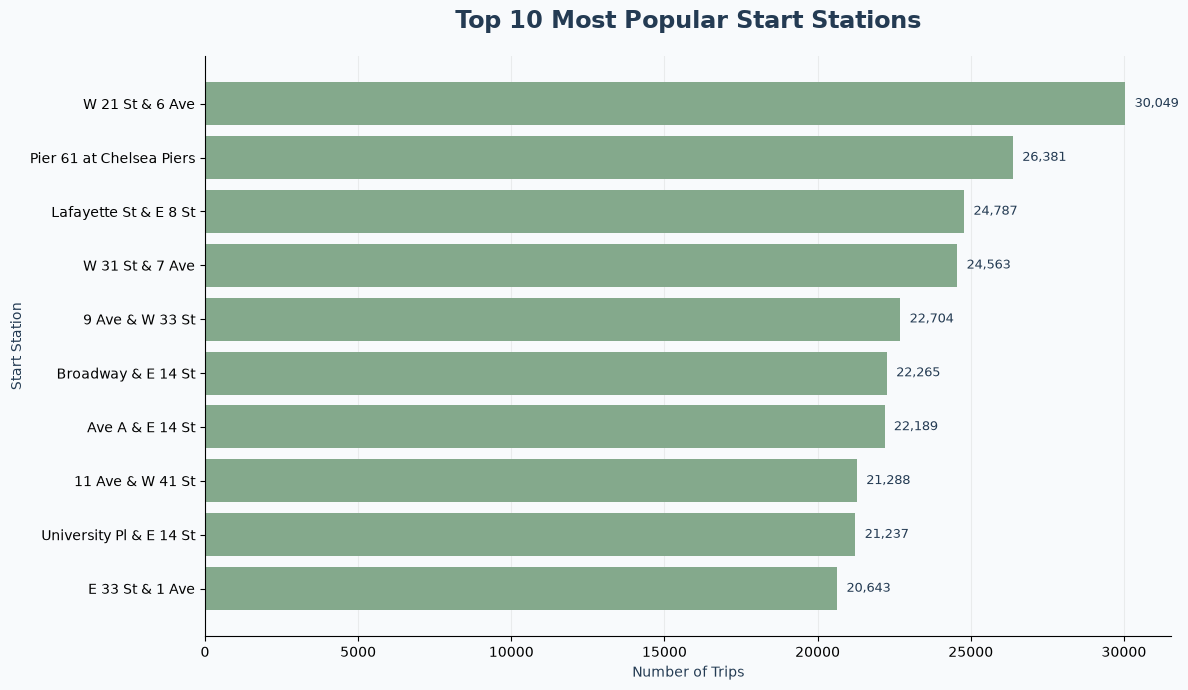

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

# Load start station data
station_data = pd.read_csv(
    "../data/processed/citibike_cleaned_features.csv",
    usecols=["start_station_name"]
)

# Remove missing station names
station_data = station_data.dropna(
    subset=["start_station_name"]
)

# Find top 10 stations
station_counts = (
    station_data["start_station_name"]
    .value_counts()
    .head(10)
    .sort_values()
)

stations = station_counts.index
values = station_counts.values

# Professional theme
NAVY = "#243B53"
SAGE = "#84A98C"
BACKGROUND = "#F8FAFC"

fig, ax = plt.subplots(figsize=(12, 7))

fig.patch.set_facecolor(BACKGROUND)
ax.set_facecolor(BACKGROUND)

bars = ax.barh(
    stations,
    values,
    color=SAGE
)

ax.set_title(
    "Top 10 Most Popular Start Stations",
    fontsize=17,
    fontweight="bold",
    color=NAVY,
    pad=20
)

ax.set_xlabel("Number of Trips", color=NAVY)
ax.set_ylabel("Start Station", color=NAVY)

# Add labels
for bar, value in zip(bars, values):
    ax.text(
        value + values.max() * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"{value:,.0f}",
        va="center",
        fontsize=9,
        color=NAVY
    )

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="x", alpha=0.2)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

### Interpretation

- W 21 St & 6 Ave recorded the highest number of starting trips.
- Pier 61 at Chelsea Piers was the second-most popular start station.
- E 33 St & 1 Ave recorded the lowest count among the top 10 stations.
- The results show that ride demand is concentrated at specific stations.

This analysis helps identify high-demand starting locations
and supports better station management and resource planning.

## 1.7 Top 10 Most Popular End Stations

This analysis identifies the 10 stations
where the highest number of trips ended.

The purpose is to understand popular destination stations
and travel demand across the Citi Bike network.

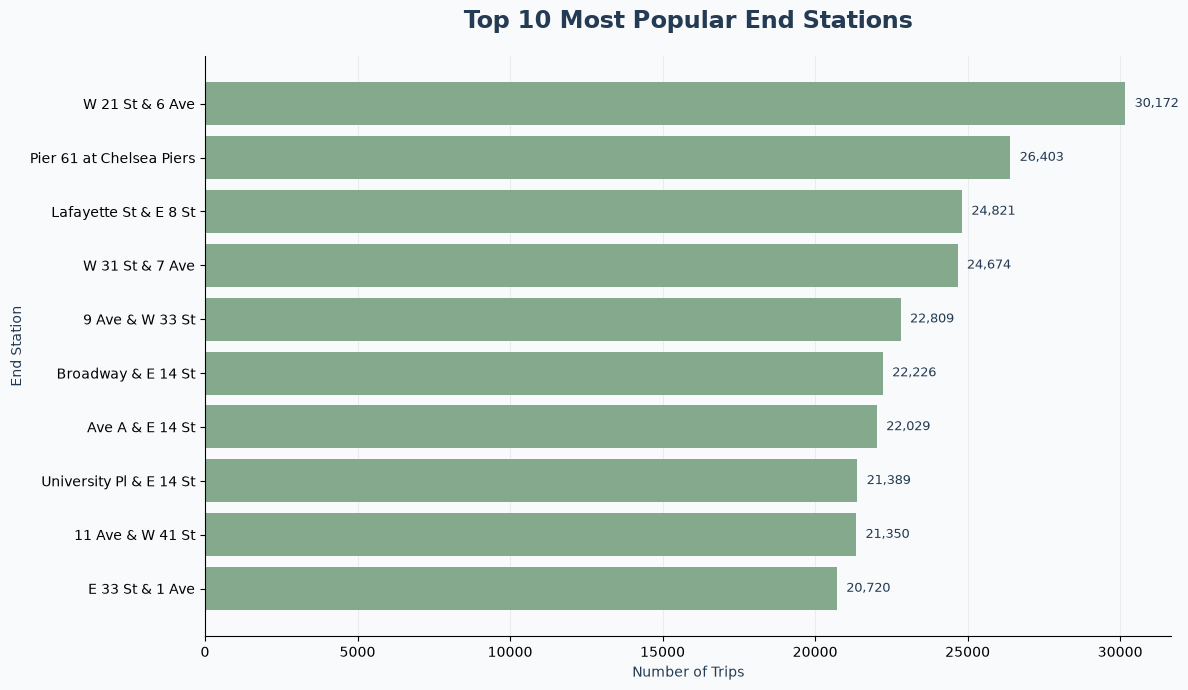

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

# Load end station data
station_data = pd.read_csv(
    "../data/processed/citibike_cleaned_features.csv",
    usecols=["end_station_name"]
)

# Remove missing station names
station_data = station_data.dropna(
    subset=["end_station_name"]
)

# Find top 10 end stations
station_counts = (
    station_data["end_station_name"]
    .value_counts()
    .head(10)
    .sort_values()
)

stations = station_counts.index
values = station_counts.values

# Professional theme
NAVY = "#243B53"
SAGE = "#84A98C"
BACKGROUND = "#F8FAFC"

fig, ax = plt.subplots(figsize=(12, 7))

fig.patch.set_facecolor(BACKGROUND)
ax.set_facecolor(BACKGROUND)

bars = ax.barh(
    stations,
    values,
    color=SAGE
)

ax.set_title(
    "Top 10 Most Popular End Stations",
    fontsize=17,
    fontweight="bold",
    color=NAVY,
    pad=20
)

ax.set_xlabel("Number of Trips", color=NAVY)
ax.set_ylabel("End Station", color=NAVY)

# Add labels
for bar, value in zip(bars, values):
    ax.text(
        value + values.max() * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"{value:,.0f}",
        va="center",
        fontsize=9,
        color=NAVY
    )

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="x", alpha=0.2)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

### Interpretation

- W 21 St & 6 Ave recorded the highest number of ending trips.
- Pier 61 at Chelsea Piers was the second-most popular end station.
- E 33 St & 1 Ave recorded the lowest count among the top 10 stations.
- The top start and end stations show similar patterns of high demand.
- These results can help identify stations with high destination demand.

This analysis helps understand popular destination stations
and supports better resource planning.

## 1.8 Ride Duration Distribution

This analysis examines the distribution of trip durations
in minutes.

The purpose is to understand common trip lengths
and identify the duration range of most rides.

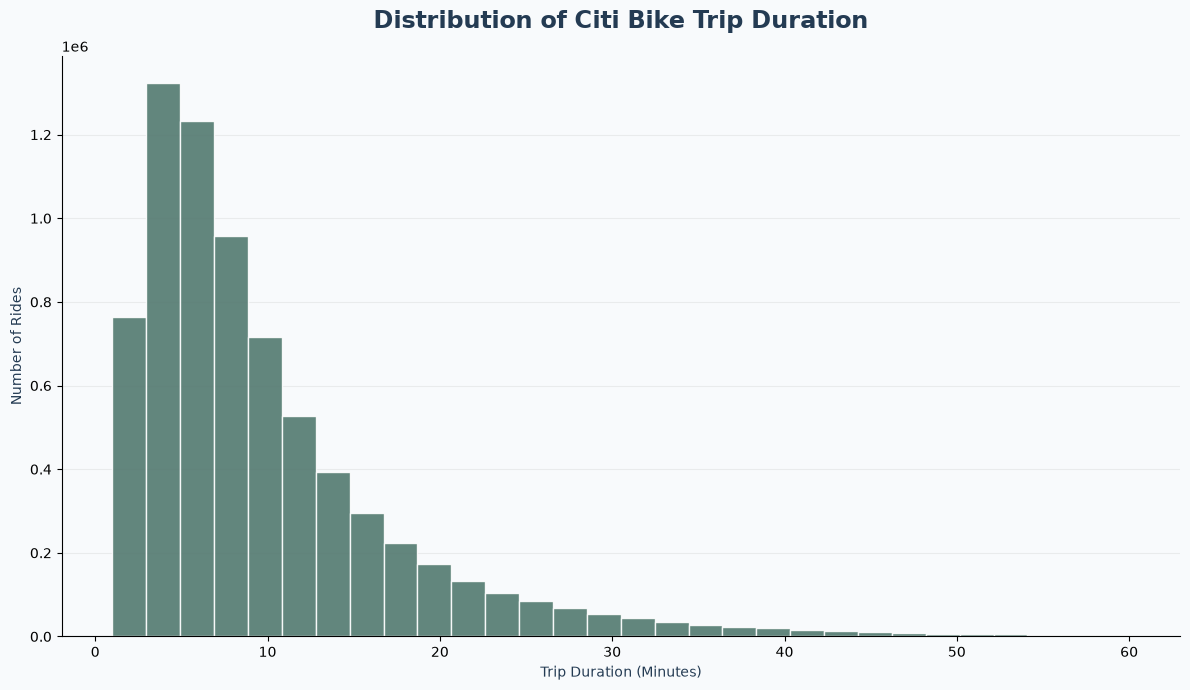

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

# Load trip duration
duration_data = pd.read_csv(
    "../data/processed/citibike_cleaned_features.csv",
    usecols=["trip_duration"]
)

# Remove missing values and limit display to 60 minutes
durations = duration_data["trip_duration"].dropna()
durations = durations[durations <= 60]

# Professional theme
NAVY = "#243B53"
TEAL = "#52796F"
BACKGROUND = "#F8FAFC"

fig, ax = plt.subplots(figsize=(12, 7))

fig.patch.set_facecolor(BACKGROUND)
ax.set_facecolor(BACKGROUND)

ax.hist(
    durations,
    bins=30,
    color=TEAL,
    edgecolor="white",
    alpha=0.9
)

ax.set_title(
    "Distribution of Citi Bike Trip Duration",
    fontsize=17,
    fontweight="bold",
    color=NAVY,
    pad=20
)

ax.set_xlabel("Trip Duration (Minutes)", color=NAVY)
ax.set_ylabel("Number of Rides", color=NAVY)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", alpha=0.2)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

### Interpretation

- Most trips have a duration of approximately 3–10 minutes.
- The distribution is right-skewed, with fewer longer trips.
- The number of rides decreases as trip duration increases.
- A small number of trips last more than 30 minutes.

This analysis helps us understand common trip durations
and the overall riding behavior of Citi Bike users.

## 1.9 Ride Distance Distribution

This analysis examines the distribution of trip distances
in kilometers.

The purpose is to understand common travel distances
and identify the distance range of most rides.

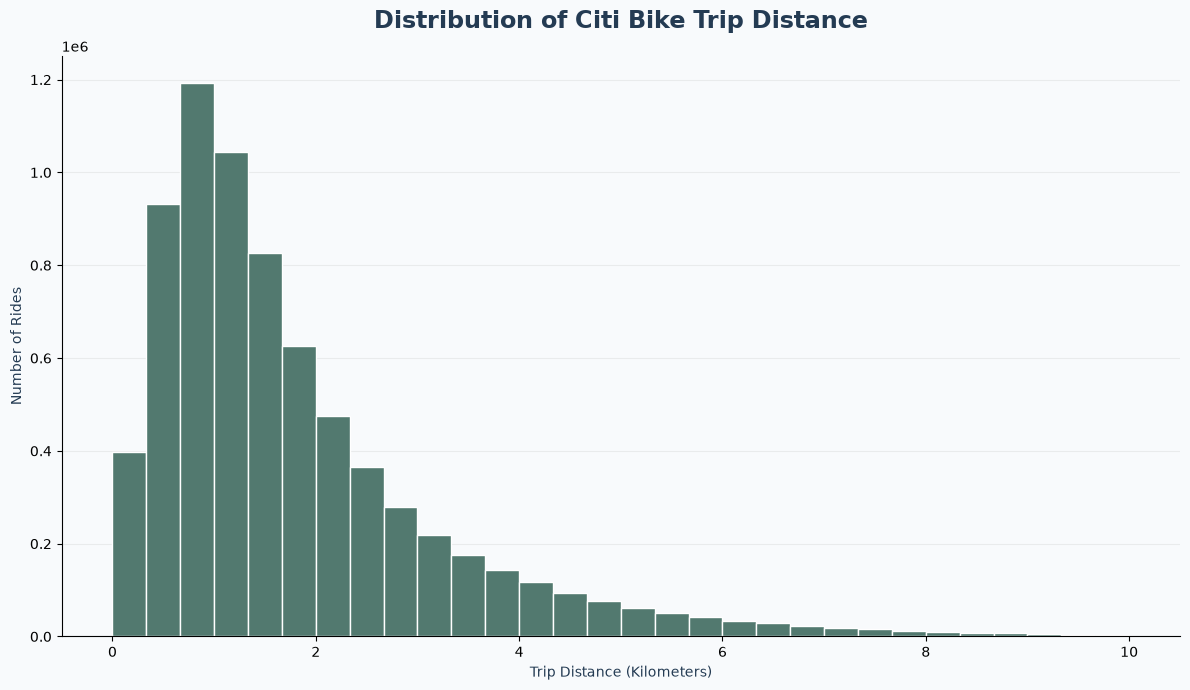

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Professional theme
NAVY = "#243B53"
TEAL = "#52796F"
BACKGROUND = "#F8FAFC"

# Define histogram bins (0–10 km)
bins = np.linspace(0, 10, 31)
hist_counts = np.zeros(len(bins) - 1)

# Read CSV in small chunks
file_path = "../data/processed/citibike_cleaned_features.csv"

for chunk in pd.read_csv(
    file_path,
    usecols=["distance_km"],
    chunksize=100000
):
    distances = pd.to_numeric(
        chunk["distance_km"],
        errors="coerce"
    ).dropna()

    distances = distances[
        (distances >= 0) & (distances <= 10)
    ]

    counts, _ = np.histogram(
        distances,
        bins=bins
    )

    hist_counts += counts

# Create graph
fig, ax = plt.subplots(figsize=(12, 7))

fig.patch.set_facecolor(BACKGROUND)
ax.set_facecolor(BACKGROUND)

ax.bar(
    bins[:-1],
    hist_counts,
    width=np.diff(bins),
    align="edge",
    color=TEAL,
    edgecolor="white"
)

ax.set_title(
    "Distribution of Citi Bike Trip Distance",
    fontsize=17,
    fontweight="bold",
    color=NAVY,
    pad=20
)

ax.set_xlabel("Trip Distance (Kilometers)", color=NAVY)
ax.set_ylabel("Number of Rides", color=NAVY)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", alpha=0.2)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

### Interpretation

- Most Citi Bike trips cover a short distance.
- The highest number of trips are concentrated around 0.5–2 kilometers.
- The distribution is right-skewed, with fewer longer-distance trips.
- Some trips extend beyond 5 kilometers.

This analysis helps us understand the common travel
distances of Citi Bike users.

## 1.10 Average Trip Distance by User Type

This analysis compares the average trip distance
between members and casual users.

The purpose is to understand differences in travel
patterns between the two user groups.

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

file_path = "../data/processed/citibike_cleaned_features.csv"

# Store total distance and count for each user type
distance_sum = {}
distance_count = {}

for chunk in pd.read_csv(
    file_path,
    usecols=["member_casual", "distance_km"],
    chunksize=100000
):
    chunk["distance_km"] = pd.to_numeric(
        chunk["distance_km"],
        errors="coerce"
    )

    chunk = chunk.dropna(
        subset=["member_casual", "distance_km"]
    )

    grouped = chunk.groupby("member_casual")["distance_km"].agg(
        ["sum", "count"]
    )

    for user_type, row in grouped.iterrows():
        distance_sum[user_type] = (
            distance_sum.get(user_type, 0) + row["sum"]
        )

        distance_count[user_type] = (
            distance_count.get(user_type, 0) + row["count"]
        )

# Calculate averages
avg_distance = {
    user_type: distance_sum[user_type] / distance_count[user_type]
    for user_type in distance_sum
}

print("Average Trip Distance (km):")
print(avg_distance)

Average Trip Distance (km):
{'casual': np.float64(2.0245361445601104), 'member': np.float64(1.7909883510218845)}


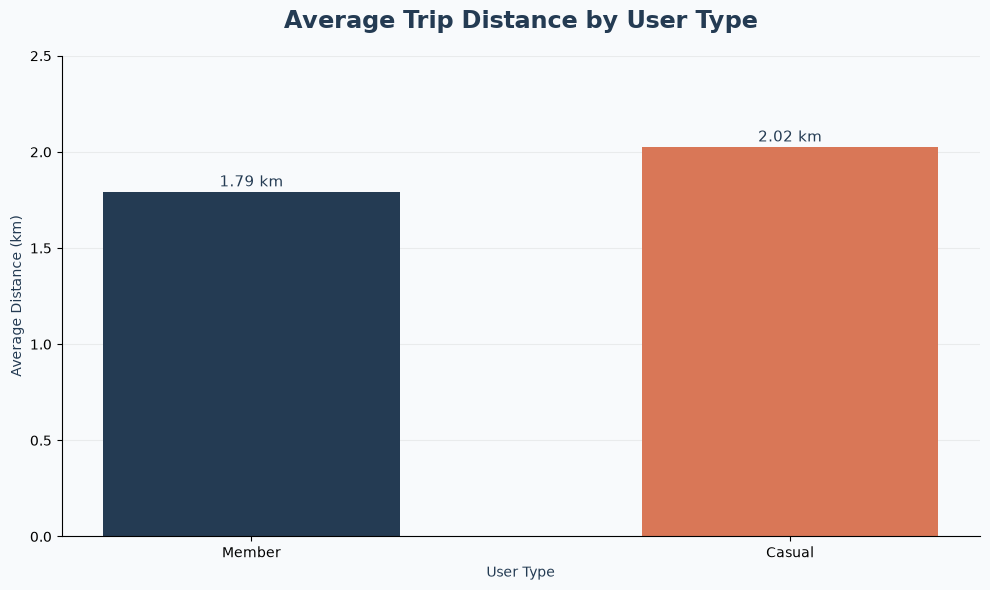

In [12]:
import matplotlib.pyplot as plt

# Average distances obtained from chunk processing
user_types = ["Member", "Casual"]
avg_distances = [
    avg_distance.get("member", 0),
    avg_distance.get("casual", 0)
]
# Professional color theme
NAVY = "#243B53"
TEAL = "#52796F"
CORAL = "#D97757"
BACKGROUND = "#F8FAFC"

fig, ax = plt.subplots(figsize=(10, 6))

fig.patch.set_facecolor(BACKGROUND)
ax.set_facecolor(BACKGROUND)

bars = ax.bar(
    user_types,
    avg_distances,
    color=[NAVY, CORAL],
    width=0.55
)

ax.set_title(
    "Average Trip Distance by User Type",
    fontsize=17,
    fontweight="bold",
    color=NAVY,
    pad=20
)

ax.set_xlabel("User Type", color=NAVY)
ax.set_ylabel("Average Distance (km)", color=NAVY)

for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.03,
        f"{height:.2f} km",
        ha="center",
        fontsize=11,
        color=NAVY
    )

ax.set_ylim(0, 2.5)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", alpha=0.2)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

### Interpretation

- Casual users have a higher average trip distance
  than members.
-- Average trip distance differs between casual users and members.
- The exact averages are shown in the chart and calculated dynamically.
- This suggests differences in travel patterns
  between the two user groups.

Note: Average distance alone does not explain
the reasons for these differences.

## 1.11 Ride Count by User Type and Day

This analysis compares the number of rides taken by
members and casual users on each day of the week.

The purpose is to identify differences in weekly
riding patterns between the two user groups.

            member  casual
Monday      905042   94123
Tuesday    1001719  104101
Wednesday  1006478  108987
Thursday    993002  103643
Friday     1029746  133984
Saturday    837607  173104
Sunday      693505  119453


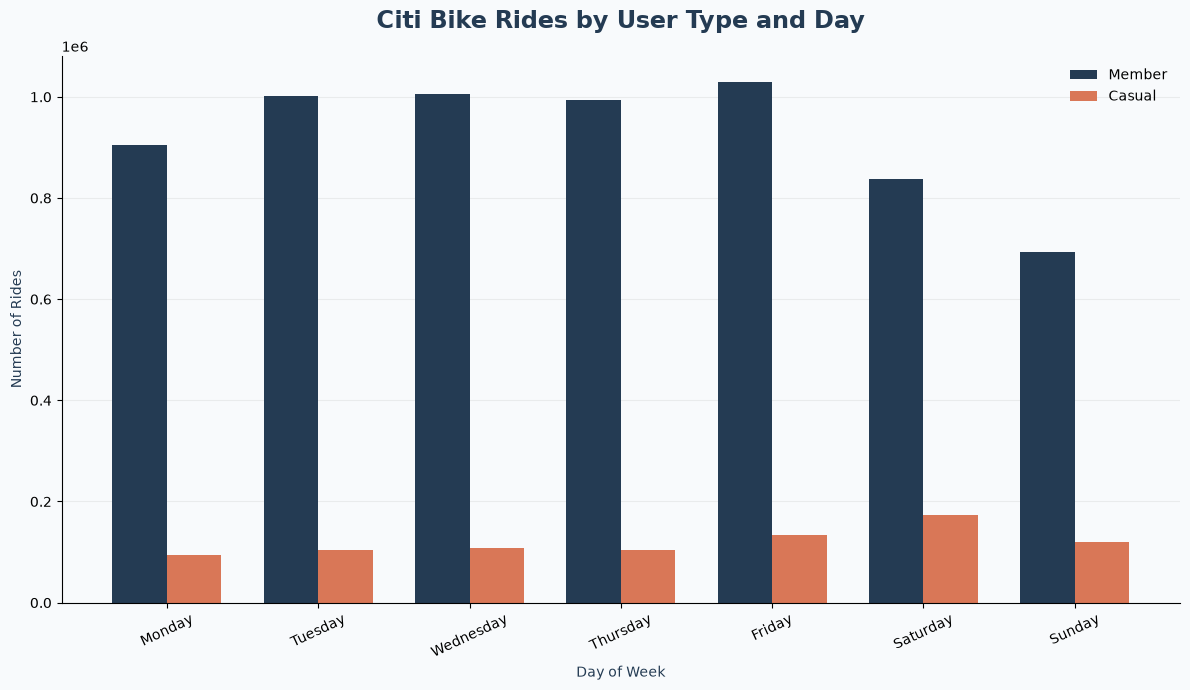

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

file_path = "../data/processed/citibike_cleaned_features.csv"

day_order = [
    "Monday", "Tuesday", "Wednesday",
    "Thursday", "Friday", "Saturday", "Sunday"
]

# Create an empty count table
ride_counts = pd.DataFrame(
    0,
    index=day_order,
    columns=["member", "casual"]
)

# Read data in chunks
for chunk in pd.read_csv(
    file_path,
    usecols=["day_of_week", "member_casual"],
    chunksize=100000
):
    counts = pd.crosstab(
        chunk["day_of_week"],
        chunk["member_casual"]
    )

    for day in counts.index:
        if day in ride_counts.index:
            for user_type in ["member", "casual"]:
                if user_type in counts.columns:
                    ride_counts.loc[day, user_type] += counts.loc[
                        day, user_type
                    ]

print(ride_counts)

# Professional theme
NAVY = "#243B53"
CORAL = "#D97757"
BACKGROUND = "#F8FAFC"

x = np.arange(len(day_order))
width = 0.36

fig, ax = plt.subplots(figsize=(12, 7))

fig.patch.set_facecolor(BACKGROUND)
ax.set_facecolor(BACKGROUND)

bars1 = ax.bar(
    x - width / 2,
    ride_counts["member"],
    width,
    label="Member",
    color=NAVY
)

bars2 = ax.bar(
    x + width / 2,
    ride_counts["casual"],
    width,
    label="Casual",
    color=CORAL
)

ax.set_title(
    "Citi Bike Rides by User Type and Day",
    fontsize=17,
    fontweight="bold",
    color=NAVY,
    pad=20
)

ax.set_xlabel("Day of Week", color=NAVY)
ax.set_ylabel("Number of Rides", color=NAVY)

ax.set_xticks(x)
ax.set_xticklabels(day_order)
ax.legend(frameon=False)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", alpha=0.2)
ax.set_axisbelow(True)

plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

### Interpretation

- Members account for more rides than casual users on every day of the week.
- Friday has the highest number of rides for both user types.
- Sunday has the lowest number of member rides.
- Casual users show higher usage on Friday and Saturday compared with weekdays.
- Members maintain consistently high ride counts throughout the week.

This analysis helps us understand how usage patterns differ
between members and casual users across the week.

# 2. Weather Data Integration

This section integrates historical weather data with
NYC Citi Bike trip data for January–March 2025.

The weather data will be collected using the Open-Meteo
Historical Weather API.

We will examine weather conditions such as:
- Temperature
- Rainfall
- Wind Speed

The purpose is to analyze how weather conditions
may influence Citi Bike usage.

## Weather Analysis Scope

- Location: New York City
- Period: January–March 2025
- Weather source: Open-Meteo Historical Weather API
- Analysis level: Daily
- Weather variables: Temperature, rainfall, and wind speed

The results describe relationships within the selected study period.
They should not be interpreted as proof of causation.

## 2.1 Collect Historical Weather Data

Historical weather data will be collected using the
Open-Meteo Historical Weather API.

The location is New York City.

The collected variables include:
- Temperature
- Rainfall
- Wind Speed

The data covers January–March 2025.

In [14]:
import requests
import pandas as pd
import os

# New York City coordinates
latitude = 40.7128
longitude = -74.0060

# Open-Meteo Historical Weather API
url = "https://archive-api.open-meteo.com/v1/archive"

params = {
    "latitude": latitude,
    "longitude": longitude,
    "start_date": "2025-01-01",
    "end_date": "2025-03-31",
    "daily": [
        "temperature_2m_mean",
        "rain_sum",
        "wind_speed_10m_max"
    ],
    "timezone": "America/New_York"
}

response = requests.get(url, params=params, timeout=30)
response.raise_for_status()

print("Status Code:", response.status_code)

weather_json = response.json()

weather_df = pd.DataFrame({
    "date": weather_json["daily"]["time"],
    "temperature_mean": weather_json["daily"]["temperature_2m_mean"],
    "rain_sum": weather_json["daily"]["rain_sum"],
    "wind_speed_max": weather_json["daily"]["wind_speed_10m_max"]
})

print(weather_df.head())
print(weather_df.shape)

Status Code: 200
         date  temperature_mean  rain_sum  wind_speed_max
0  2025-01-01               7.4       4.5            23.2
1  2025-01-02               2.6       0.0            25.1
2  2025-01-03               0.4       0.0            17.1
3  2025-01-04              -1.4       0.0            26.1
4  2025-01-05              -2.2       0.0            19.9
(90, 4)


In [15]:
# Create external data folder
os.makedirs("../data/external", exist_ok=True)

# Save weather data
weather_df.to_csv(
    "../data/external/weather_daily_2025.csv",
    index=False
)

print("Weather data saved successfully!")
print(weather_df.info())

Weather data saved successfully!
<class 'pandas.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   date              90 non-null     str    
 1   temperature_mean  90 non-null     float64
 2   rain_sum          90 non-null     float64
 3   wind_speed_max    90 non-null     float64
dtypes: float64(3), str(1)
memory usage: 3.8 KB
None


In [16]:
import pandas as pd

daily_counts = []

for chunk in pd.read_csv(
    "../data/processed/citibike_cleaned_features.csv",
    usecols=["trip_date"],
    chunksize=100000
):
    counts = chunk["trip_date"].value_counts()
    daily_counts.append(counts)

daily_rides = (
    pd.concat(daily_counts, axis=1)
    .fillna(0)
    .sum(axis=1)
    .reset_index()
)

daily_rides.columns = ["trip_date", "ride_count"]

daily_rides["trip_date"] = pd.to_datetime(
    daily_rides["trip_date"]
)

daily_rides = daily_rides.sort_values("trip_date")

print(daily_rides.head())
print(daily_rides.shape)

    trip_date  ride_count
14 2024-12-31       182.0
12 2025-01-01     51280.0
3  2025-01-02     71631.0
2  2025-01-03     75194.0
11 2025-01-04     55187.0
(91, 2)


In [17]:
# Prepare date columns
daily_rides["trip_date"] = pd.to_datetime(
    daily_rides["trip_date"]
)

weather_df["date"] = pd.to_datetime(
    weather_df["date"]
)

# Rename weather date column
weather_df = weather_df.rename(
    columns={"date": "trip_date"}
)

# Merge both datasets
daily_weather = pd.merge(
    daily_rides,
    weather_df,
    on="trip_date",
    how="left"
)

print(daily_weather.head())
print(daily_weather.shape)
print(daily_weather.isnull().sum())

   trip_date  ride_count  temperature_mean  rain_sum  wind_speed_max
0 2024-12-31       182.0               NaN       NaN             NaN
1 2025-01-01     51280.0               7.4       4.5            23.2
2 2025-01-02     71631.0               2.6       0.0            25.1
3 2025-01-03     75194.0               0.4       0.0            17.1
4 2025-01-04     55187.0              -1.4       0.0            26.1
(91, 5)
trip_date           0
ride_count          0
temperature_mean    1
rain_sum            1
wind_speed_max      1
dtype: int64


In [18]:
# Remove rows with missing weather data
daily_weather = daily_weather.dropna()

# Reset index
daily_weather = daily_weather.reset_index(drop=True)

print(daily_weather.head())
print(daily_weather.shape)
print(daily_weather.isnull().sum())

   trip_date  ride_count  temperature_mean  rain_sum  wind_speed_max
0 2025-01-01     51280.0               7.4       4.5            23.2
1 2025-01-02     71631.0               2.6       0.0            25.1
2 2025-01-03     75194.0               0.4       0.0            17.1
3 2025-01-04     55187.0              -1.4       0.0            26.1
4 2025-01-05     52064.0              -2.2       0.0            19.9
(90, 5)
trip_date           0
ride_count          0
temperature_mean    0
rain_sum            0
wind_speed_max      0
dtype: int64


## Final Dataset Overview

The final dataset combines daily Citi Bike ride counts
with historical weather measurements.

Each row represents one day in the analysis period.

The dataset includes:
- Daily ride count
- Average temperature
- Total rainfall
- Maximum wind speed
- Date-based features

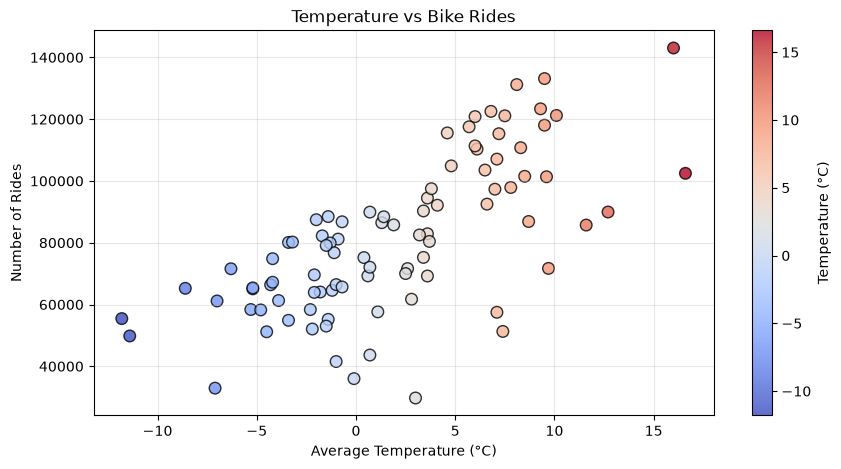

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

scatter = plt.scatter(
    daily_weather["temperature_mean"],
    daily_weather["ride_count"],
    c=daily_weather["temperature_mean"],
    cmap="coolwarm",
    s=70,
    alpha=0.8,
    edgecolors="black"
)

plt.colorbar(scatter, label="Temperature (°C)")

plt.xlabel("Average Temperature (°C)")
plt.ylabel("Number of Rides")
plt.title("Temperature vs Bike Rides")

plt.grid(alpha=0.3)
plt.show()

In [20]:
correlation = daily_weather[
    ["temperature_mean", "ride_count"]
].corr()

print(correlation)

                  temperature_mean  ride_count
temperature_mean          1.000000    0.691255
ride_count                0.691255    1.000000


In [21]:
weather_correlation = daily_weather[
    [
        "temperature_mean",
        "rain_sum",
        "wind_speed_max",
        "ride_count"
    ]
].corr()

print(weather_correlation)

                  temperature_mean  rain_sum  wind_speed_max  ride_count
temperature_mean          1.000000  0.452738        0.196369    0.691255
rain_sum                  0.452738  1.000000        0.248787   -0.030765
wind_speed_max            0.196369  0.248787        1.000000   -0.029969
ride_count                0.691255 -0.030765       -0.029969    1.000000


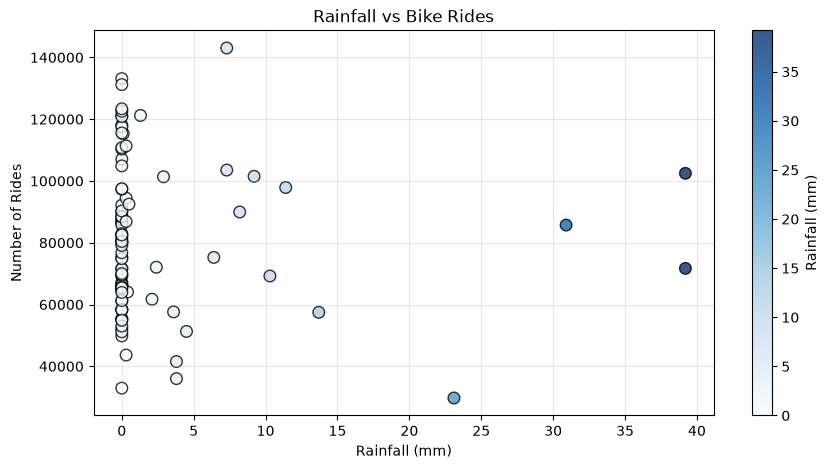

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

scatter = plt.scatter(
    daily_weather["rain_sum"],
    daily_weather["ride_count"],
    c=daily_weather["rain_sum"],
    cmap="Blues",
    s=70,
    alpha=0.8,
    edgecolors="black"
)

plt.colorbar(scatter, label="Rainfall (mm)")

plt.xlabel("Rainfall (mm)")
plt.ylabel("Number of Rides")
plt.title("Rainfall vs Bike Rides")

plt.grid(alpha=0.3)
plt.show()

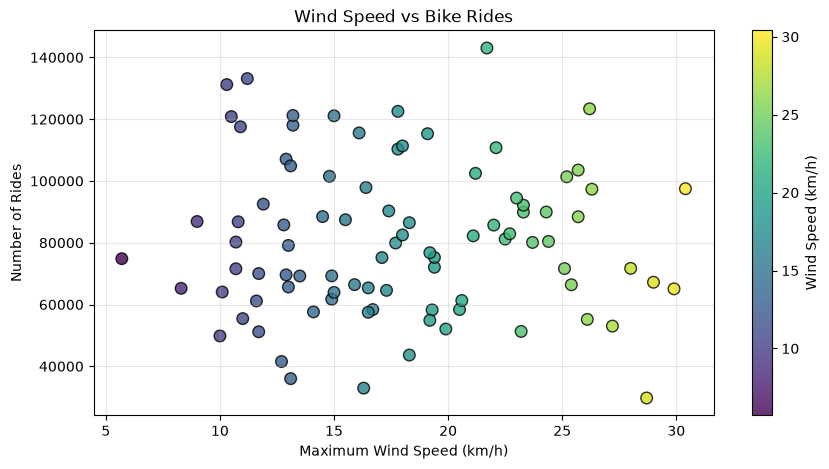

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

scatter = plt.scatter(
    daily_weather["wind_speed_max"],
    daily_weather["ride_count"],
    c=daily_weather["wind_speed_max"],
    cmap="viridis",
    s=70,
    alpha=0.8,
    edgecolors="black"
)

plt.colorbar(scatter, label="Wind Speed (km/h)")

plt.xlabel("Maximum Wind Speed (km/h)")
plt.ylabel("Number of Rides")
plt.title("Wind Speed vs Bike Rides")

plt.grid(alpha=0.3)
plt.show()

## Weather Correlation Interpretation

Temperature showed a positive relationship with daily ride counts.

Rainfall and wind speed showed weak relationships with daily ride counts.

These correlations describe associations in the selected study period
and do not establish causation.

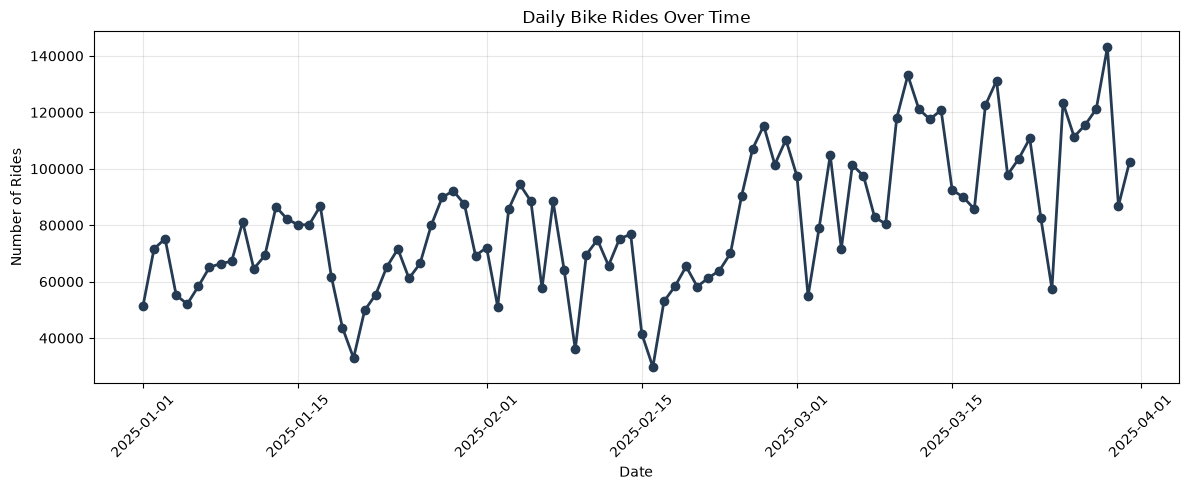

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(
    daily_weather["trip_date"],
    daily_weather["ride_count"],
    marker="o",
    linewidth=2,
    color="#243B53"
)

plt.xlabel("Date")
plt.ylabel("Number of Rides")
plt.title("Daily Bike Rides Over Time")

plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

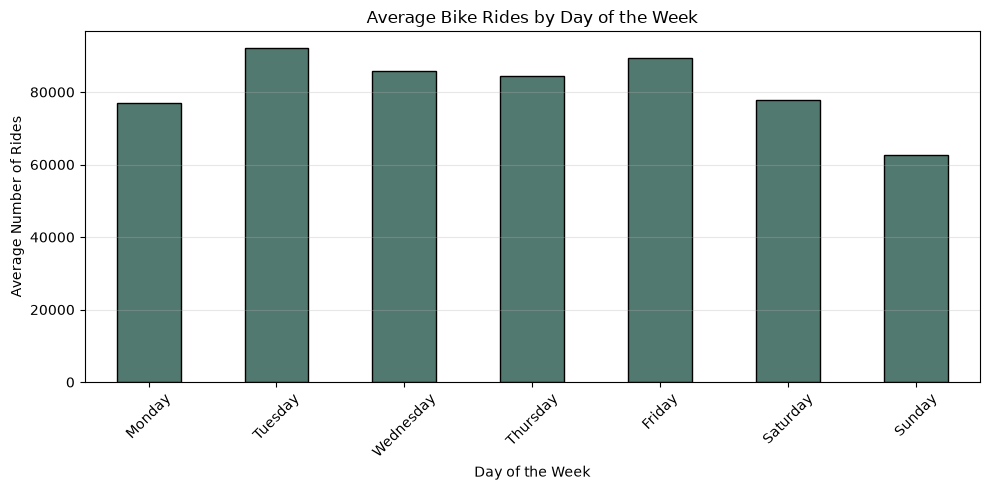

In [25]:
import matplotlib.pyplot as plt

# Create day of week
daily_weather["day_name"] = (
    daily_weather["trip_date"].dt.day_name()
)

# Calculate average rides by day
day_rides = (
    daily_weather.groupby("day_name")["ride_count"]
    .mean()
    .reindex([
        "Monday", "Tuesday", "Wednesday",
        "Thursday", "Friday", "Saturday", "Sunday"
    ])
)

plt.figure(figsize=(10, 5))

day_rides.plot(
    kind="bar",
    color="#52796F",
    edgecolor="black"
)

plt.xlabel("Day of the Week")
plt.ylabel("Average Number of Rides")
plt.title("Average Bike Rides by Day of the Week")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

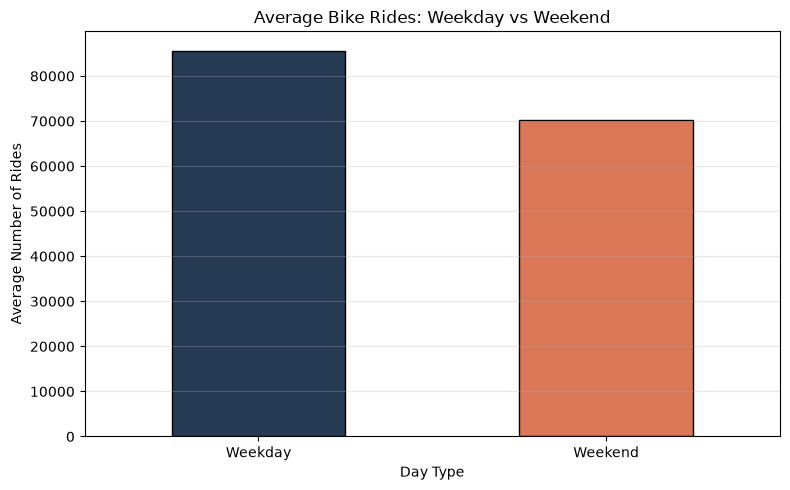

In [26]:
import matplotlib.pyplot as plt

# Create weekday/weekend category
daily_weather["day_type"] = daily_weather["trip_date"].dt.dayofweek.map(
    lambda x: "Weekend" if x >= 5 else "Weekday"
)

# Calculate average rides
day_type_rides = daily_weather.groupby("day_type")["ride_count"].mean()

plt.figure(figsize=(8, 5))

day_type_rides.plot(
    kind="bar",
    color=["#243B53", "#D97757"],
    edgecolor="black"
)

plt.xlabel("Day Type")
plt.ylabel("Average Number of Rides")
plt.title("Average Bike Rides: Weekday vs Weekend")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [27]:
# Create output folder
import os

os.makedirs("../data/processed", exist_ok=True)

# Save merged dataset
daily_weather.to_csv(
    "../data/processed/citibike_daily_weather.csv",
    index=False
)

print("Final dataset saved successfully!")
print(daily_weather.shape)

Final dataset saved successfully!
(90, 7)


In [28]:
# Final project insights

print("Average daily rides:",
      round(daily_weather["ride_count"].mean()))

print("Highest daily rides:",
      round(daily_weather["ride_count"].max()))

print("Lowest daily rides:",
      round(daily_weather["ride_count"].min()))

print("\nWeather Correlations:")
print(
    daily_weather[
        [
            "temperature_mean",
            "rain_sum",
            "wind_speed_max",
            "ride_count"
        ]
    ].corr()["ride_count"]
)

Average daily rides: 81159
Highest daily rides: 143039
Lowest daily rides: 29733

Weather Correlations:
temperature_mean    0.691255
rain_sum           -0.030765
wind_speed_max     -0.029969
ride_count          1.000000
Name: ride_count, dtype: float64


## Project Summary

### Key Findings

- Daily ride demand varied across the study period.
- Temperature showed a positive relationship with daily ride counts.
- Rainfall and wind speed showed weak relationships with daily ride counts.
- Ride demand differed between weekdays and weekends.

### Data Quality

- Zero-distance trips were identified during validation.
- These records were retained and documented for transparency.
- Weather analysis was limited to the available study period.

### Conclusion

This analysis explores Citi Bike usage patterns and the relationship
between ride demand and weather conditions. The findings can support
future demand forecasting and operational planning.

## Limitations

- Weather analysis covers only January to March 2025.
- Correlation does not prove causation.
- Zero-distance trips were retained during analysis.
- Weather data was analyzed at the daily level.

## Future Scope

- Build a machine learning model for ride demand forecasting.
- Analyze hourly weather and ride patterns.
- Include holidays and special events.
- Develop an interactive dashboard using Power BI or Streamlit.